# Risk Issue & Remediation Analytics
Operational risk issue tracking analysis — Analyst-Risk Management project

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

## 1. Load and inspect the data

In [3]:
df = pd.read_csv("risk_issues_dataset.csv", parse_dates=["Open_Date", "Target_Close_Date", "Actual_Close_Date"])

In [4]:
df.head()

,Issue_ID,Business_Unit,Risk_Category,Severity,Root_Cause_Category,Control_Test_Result,Open_Date,Target_Close_Date,Actual_Close_Date,SLA_Breach,Recurrence_Flag
0,ISS-0001,Cards,Internal Fraud,Low,Human Error,Fail,2026-04-12,2026-07-11,NaT,False,True
1,ISS-0002,Payments Ops,"Execution, Delivery & Process Management",High,Human Error,Fail,2025-12-10,2026-01-09,2025-12-29,False,False
2,ISS-0003,Retail Banking,"Execution, Delivery & Process Management",Medium,System Failure,Fail,2025-02-28,2025-04-29,2025-04-08,False,False
3,ISS-0004,Retail Banking,Damage to Physical Assets,Medium,Process Gap,Pass,2025-09-01,2025-10-31,2025-10-28,False,False
4,ISS-0005,Retail Banking,"Execution, Delivery & Process Management",Low,Documentation Gap,Pass,2025-12-12,2026-03-12,NaT,True,False


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Issue_ID             2200 non-null   str           
 1   Business_Unit        2200 non-null   str           
 2   Risk_Category        2200 non-null   str           
 3   Severity             2200 non-null   str           
 4   Root_Cause_Category  2200 non-null   str           
 5   Control_Test_Result  2200 non-null   str           
 6   Open_Date            2200 non-null   datetime64[us]
 7   Target_Close_Date    2200 non-null   datetime64[us]
 8   Actual_Close_Date    1799 non-null   datetime64[us]
 9   SLA_Breach           2200 non-null   bool          
 10  Recurrence_Flag      2200 non-null   bool          
dtypes: bool(2), datetime64[us](3), str(6)
memory usage: 159.1 KB


In [6]:
df.shape

(2200, 11)

In [6]:
df.isna().sum()

Issue_ID                 0
Business_Unit            0
Risk_Category            0
Severity                 0
Root_Cause_Category      0
Control_Test_Result      0
Open_Date                0
Target_Close_Date        0
Actual_Close_Date      401
SLA_Breach               0
Recurrence_Flag          0
dtype: int64

## 2. Trend analysis — issue volume over time

In [7]:
df["Open_Month"] = df["Open_Date"].dt.to_period("M")
monthly = df.groupby("Open_Month").size()
monthly

Open_Month
2025-01    122
2025-02    111
2025-03    108
2025-04    140
2025-05    133
2025-06    123
2025-07    124
2025-08    131
2025-09    131
2025-10    110
2025-11    116
2025-12    125
2026-01    118
2026-02    122
2026-03    117
2026-04    110
2026-05    131
2026-06    128
Freq: M, dtype: int64

In [8]:
monthly.idxmax(), monthly.max()

(Period('2025-04', 'M'), np.int64(140))

In [9]:
df["Business_Unit"].value_counts()

Business_Unit
Retail Banking         516
Cards                  438
Payments Ops           391
Digital Channels       351
Merchant Services      295
Corporate Functions    209
Name: count, dtype: int64

In [10]:
df.groupby(["Business_Unit", "Risk_Category"]).size().sort_values(ascending=False).head(5)

Business_Unit     Risk_Category                           
Retail Banking    Execution, Delivery & Process Management    164
Cards             Execution, Delivery & Process Management    157
Payments Ops      Execution, Delivery & Process Management    121
Digital Channels  Execution, Delivery & Process Management    120
Retail Banking    Business Disruption & System Failures       117
dtype: int64

## 3. Root cause Pareto analysis

In [11]:
rc_counts = df["Root_Cause_Category"].value_counts()
rc_pct = (rc_counts / rc_counts.sum() * 100).round(1)
rc_pct

Root_Cause_Category
Process Gap             31.1
System Failure          25.1
Human Error             21.0
Third-Party / Vendor    13.7
Documentation Gap        9.1
Name: count, dtype: float64

In [12]:
pareto = pd.DataFrame({"Count": rc_counts, "Pct": rc_pct, "Cumulative_Pct": rc_pct.cumsum().round(1)})
pareto

,Count,Pct,Cumulative_Pct
Root_Cause_Category,,,
Process Gap,684,31.1,31.1
System Failure,552,25.1,56.2
Human Error,463,21.0,77.2
Third-Party / Vendor,301,13.7,90.9
Documentation Gap,200,9.1,100.0


## 4. Control effectiveness — fail rate by severity and business unit

In [13]:
df.groupby("Severity")["Control_Test_Result"].apply(lambda x: (x == "Fail").mean() * 100).round(1)

Severity
High      55.3
Low       16.9
Medium    31.8
Name: Control_Test_Result, dtype: float64

In [14]:
df.groupby("Business_Unit")["Control_Test_Result"].apply(lambda x: (x == "Fail").mean() * 100).round(1)

Business_Unit
Cards                  29.9
Corporate Functions    29.7
Digital Channels       28.8
Merchant Services      30.2
Payments Ops           27.9
Retail Banking         29.5
Name: Control_Test_Result, dtype: float64

## 5. SLA breach analysis

In [15]:
df["SLA_Breach"].mean() * 100

np.float64(44.18181818181818)

In [16]:
df.groupby("Severity")["SLA_Breach"].mean() * 100

Severity
High      43.465046
Low       42.857143
Medium    45.621181
Name: SLA_Breach, dtype: float64

In [17]:
df.groupby("Business_Unit")["SLA_Breach"].mean() * 100

Business_Unit
Cards                  44.063927
Corporate Functions    43.540670
Digital Channels       42.735043
Merchant Services      48.813559
Payments Ops           41.687980
Retail Banking         44.767442
Name: SLA_Breach, dtype: float64

In [18]:
df.groupby("Risk_Category")["SLA_Breach"].mean() * 100

Risk_Category
Business Disruption & System Failures       44.466403
Clients, Products & Business Practices      45.530726
Damage to Physical Assets                   41.095890
Employment Practices & Workplace Safety     41.573034
Execution, Delivery & Process Management    44.474394
External Fraud                              47.659574
Internal Fraud                              35.185185
Name: SLA_Breach, dtype: float64

## 6. Recurrence analysis

In [19]:
df["Recurrence_Flag"].mean() * 100, df["Recurrence_Flag"].sum()

(np.float64(4.045454545454545), np.int64(89))

In [20]:
df[df["Recurrence_Flag"]].groupby(["Business_Unit", "Root_Cause_Category"]).size().sort_values(ascending=False).head(5)

Business_Unit        Root_Cause_Category
Payments Ops         Process Gap            6
Cards                Process Gap            5
Corporate Functions  System Failure         5
Merchant Services    Process Gap            5
Cards                Human Error            5
dtype: int64

## 7. Current open exposure snapshot

In [21]:
open_issues = df[df["Actual_Close_Date"].isna()]
len(open_issues)

401

In [22]:
snapshot_date = pd.Timestamp("2026-06-30")
age = (snapshot_date - open_issues["Open_Date"]).dt.days
age.mean(), age.max()


(np.float64(285.3067331670823), np.int64(545))

In [23]:
(open_issues["Severity"] == "High").sum()

np.int64(55)

## 8. Key findings summary

- **Root cause concentration:** Process Gap and System Failure together account for 56.2% of all logged issues, making them the top priority for remediation focus rather than spreading effort evenly across all five root cause categories.
- **Control effectiveness scales with severity:** the control test failure rate rises sharply with issue severity — from 16.9% at Low severity to 55.3% at High severity — but stays flat across business units (27.9%-30.2%). This suggests severity, not team, is the stronger predictor of whether a control was actually working.
- **SLA breach is systemic, not localized:** the overall breach rate is 44.2%, and it stays roughly flat across severity tiers (42.9%-45.6%) and business units (41.7%-48.8%). This points to a process-wide remediation gap rather than one team or one issue type being the bottleneck.
- **Recurrence is low but concentrated:** only 4.0% of issues (89 of 2,200) are flagged as recurring, but they cluster around Payments Ops and Cards, both showing repeat Process Gap issues — a signal that fixes in these areas may be addressing symptoms rather than root causes.
- **Current open exposure:** 401 issues remain open as of the snapshot date, averaging 285 days old (oldest at 545 days), including 55 High-severity issues still unresolved — this is the headline number for a leadership-facing dashboard.

## 9. Tools used

This analysis was built using Python (pandas, numpy) for data manipulation and aggregation. Microsoft Copilot was used to assist with writing and debugging groupby/aggregation syntax during the control-effectiveness and SLA-breach sections. ChatGPT was used to help structure and tighten the language in the key findings summary above, based on the raw numbers generated from the analysis.

## 10. Visualizations

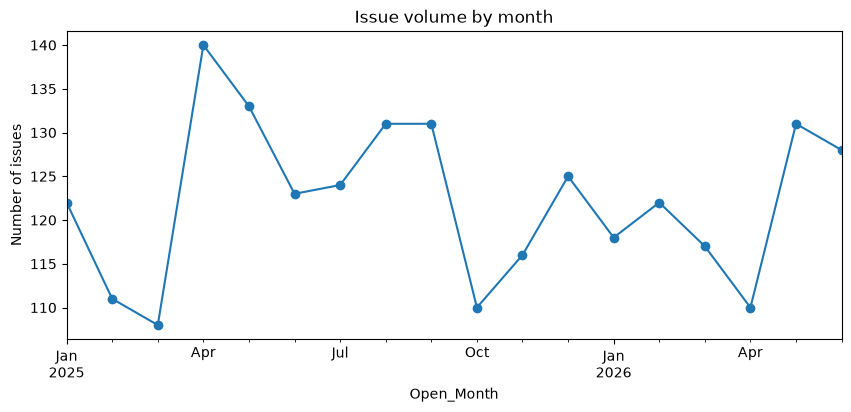

In [24]:
monthly.plot(kind="line", marker="o", figsize=(10,4), title="Issue volume by month")
plt.ylabel("Number of issues")
plt.show()

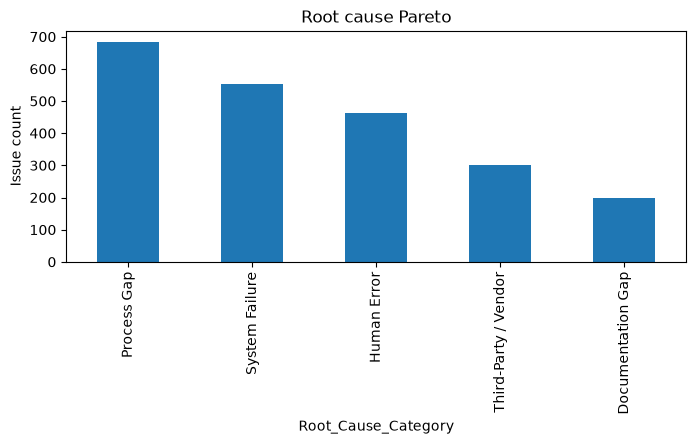

In [24]:
pareto["Count"].plot(kind="bar", figsize=(8,3), title="Root cause Pareto")
plt.ylabel("Issue count")
plt.show()

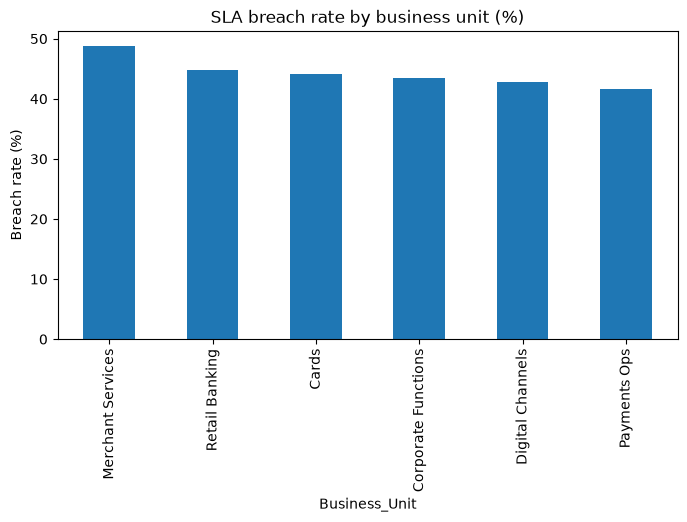

In [26]:
df.groupby("Business_Unit")["SLA_Breach"].mean().mul(100).sort_values(ascending=False).plot(kind="bar", figsize=(8,4), title="SLA breach rate by business unit (%)")
plt.ylabel("Breach rate (%)")
plt.show()